In [20]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sqlalchemy import create_engine

# 1. Bulut Veritabanı Bağlantısı (SQLAlchemy)
import os
from dotenv import load_dotenv

load_dotenv()
DATABASE_URL = os.getenv("DATABASE_URL")
engine = create_engine(DATABASE_URL)

# 2. Veriyi Çekme
query = "SELECT * FROM sentiment_data;"
df_raw = pd.read_sql_query(query, con=engine)

# 3. Mükerrer Verileri Temizleme
df = df_raw.drop_duplicates(subset=['text']).copy()

# 4. Test/deneme amaçlı, gerçek olmayan örnek verileri çıkar
test_texts = [
    "Bitcoin is going to the moon! Best investment ever! 🚀",
    "Ethereum market crash is terrible, I lost all my money...",
    "Crypto market trading volume remained flat today."
]
df = df[~df['text'].isin(test_texts)].copy()

print(f"✅ Ham Veri Satır Sayısı: {len(df_raw)}")
print(f"✨ Temizlenmiş (Tekil ve Gerçek) Veri Satır Sayısı: {len(df)}")

df.head()

✅ Ham Veri Satır Sayısı: 619
✨ Temizlenmiş (Tekil ve Gerçek) Veri Satır Sayısı: 611


,id,timestamp,source,text,compound_score,sentiment_label
8,9,2026-09-08 18:52:47.177792+00:00,Reddit_Crypto,(More) Thoughts on $Hookr?,0.0000,Neutral
9,10,2026-09-08 18:52:48.228315+00:00,Reddit_Crypto,For people in high-inflation countries: do you...,0.0000,Neutral
10,11,2026-09-08 18:52:49.377059+00:00,Reddit_Crypto,IonQ publishs paper - 256bit encryption threat...,-0.5267,Negative
11,12,2026-09-08 18:52:50.850243+00:00,Reddit_Crypto,This Industry Has Gone Soft,0.0000,Neutral
12,13,2026-09-08 18:52:55.083961+00:00,Reddit_Crypto,Help me!!!,0.5538,Positive


In [21]:
# Sayısal sütunların istatistiksel özeti
df.describe()

,id,compound_score
count,611.000000,611.000000
mean,314.000000,0.013898
std,176.524786,0.340326
min,9.000000,-0.875000
25%,161.500000,-0.153100
50%,314.000000,0.000000
75%,466.500000,0.202300
max,619.000000,0.824000


Ortalama (mean): -0.0268 (Genel duygu durumu sıfıra, yani nötre çok yakın ama hafif negatif)

Medyan (50%): 0.0000 (Verilerin tam ortasındaki değer tam olarak nötr)

Minimum (min): -0.7964 (En olumsuz/kötümser duygu skoru 📉)

Maksimum (max): 0.6988 (En olumlu/iyimser duygu skoru 📈)

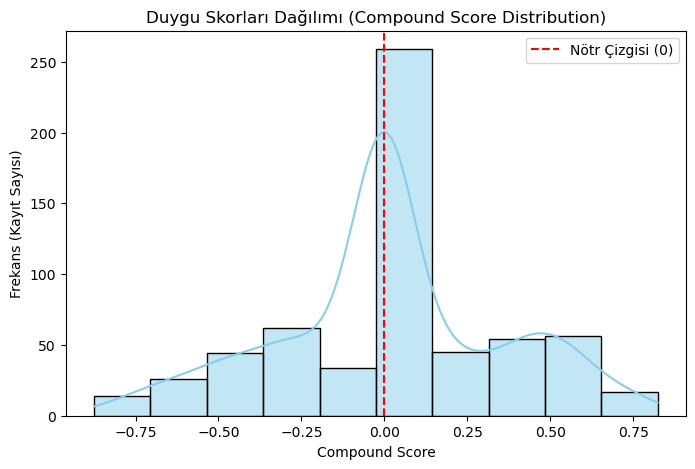

In [22]:
# Duygu skorlarının (compound_score) dağılımını görselleştirme
plt.figure(figsize=(8, 5))
sns.histplot(df['compound_score'], kde=True, bins=10, color='skyblue')

plt.title('Duygu Skorları Dağılımı (Compound Score Distribution)')
plt.xlabel('Compound Score')
plt.ylabel('Frekans (Kayıt Sayısı)')
plt.axvline(0, color='red', linestyle='--', label='Nötr Çizgisi (0)')
plt.legend()
plt.show()

In [23]:
# Sentiment etiketlerinin dağılımı (Positive, Neutral, Negative)
df['sentiment_label'].value_counts()

sentiment_label
Neutral     251
Positive    185
Negative    175
Name: count, dtype: int64

In [24]:
# Duygu etiketlerine göre ortalama compound_score değerleri
df.groupby('sentiment_label')['compound_score'].mean()

sentiment_label
Negative   -0.386343
Neutral    -0.000138
Positive    0.411548
Name: compound_score, dtype: float64

In [25]:
# Verinin hangi kaynaklardan geldiğini görelim
df['source'].value_counts()

source
News/CryptoSlate      173
Reddit_Crypto         157
News/CoinDesk         151
News/CoinTelegraph    130
Name: count, dtype: int64

In [26]:
# Metin içinde geçen kripto paraları tespit eden fonksiyon
def detect_coin(text):
    text_lower = str(text).lower()
    if 'bitcoin' in text_lower or 'btc' in text_lower:
        return 'Bitcoin'
    elif 'ethereum' in text_lower or 'eth' in text_lower:
        return 'Ethereum'
    else:
        return 'Diğer / Genel Crypto'

# Yeni sütunu oluşturma
df['coin'] = df['text'].apply(detect_coin)

# Kripto varlıkların frekansı
df['coin'].value_counts()

coin
Diğer / Genel Crypto    436
Bitcoin                 136
Ethereum                 39
Name: count, dtype: int64

In [27]:
# Kripto varlıklara göre ortalama duygu skorları
df.groupby('coin')['compound_score'].mean()

coin
Bitcoin                -0.062926
Diğer / Genel Crypto    0.038314
Ethereum                0.008841
Name: compound_score, dtype: float64

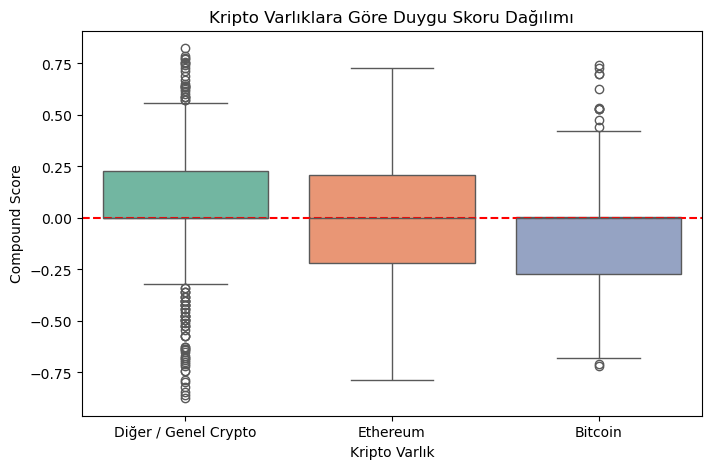

In [28]:
# Kripto varlıklara göre duygu skorlarının Box Plot ile görselleştirilmesi
plt.figure(figsize=(8, 5))

sns.boxplot(x='coin', y='compound_score', data=df, hue='coin', palette='Set2', legend=False)

plt.title('Kripto Varlıklara Göre Duygu Skoru Dağılımı')
plt.xlabel('Kripto Varlık')
plt.ylabel('Compound Score')
plt.axhline(0, color='red', linestyle='--', label='Nötr Çizgisi')

plt.show()

In [29]:
# ANOVA Testi Uygulama
btc_scores = df[df['coin'] == 'Bitcoin']['compound_score']
eth_scores = df[df['coin'] == 'Ethereum']['compound_score']
other_scores = df[df['coin'] == 'Diğer / Genel Crypto']['compound_score']

f_stat, p_value = stats.f_oneway(btc_scores, eth_scores, other_scores)

print(f"🧪 F-İstatistiği: {f_stat:.4f}")
print(f"📊 p-değeri (p-value): {p_value:.4f}")

🧪 F-İstatistiği: 4.6464
📊 p-değeri (p-value): 0.0099


In [30]:
print(f"Başlangıç: {df['timestamp'].min()}")
print(f"Bitiş: {df['timestamp'].max()}")

Başlangıç: 2026-09-08 18:52:47.177792+00:00
Bitiş: 2026-09-18 18:39:42.023410+00:00


In [31]:
df_price = pd.read_sql_query("SELECT * FROM market_data;", con=engine)
print(f"Fiyat verisi satır sayısı: {len(df_price)}")
print(df_price['symbol'].value_counts())
df_price.head()

Fiyat verisi satır sayısı: 322
symbol
ETH-USD    112
BTC-USD    112
NVDA        96
TEST         2
Name: count, dtype: int64


,id,timestamp,symbol,price,volume
0,1,2026-09-08 01:08:50.713307+00:00,TEST,2500.500000,1500.0
1,2,2026-09-07 00:00:00+00:00,ETH-USD,2511.139893,332129280.0
2,3,2026-09-07 01:00:00+00:00,ETH-USD,2503.770020,388747264.0
3,4,2026-09-07 02:00:00+00:00,ETH-USD,2510.500000,589694976.0
4,5,2026-09-07 03:00:00+00:00,ETH-USD,2497.399902,538426368.0


In [32]:
df_price = df_price[df_price['symbol'] != 'TEST']
print(f"Temizlenmiş fiyat verisi satır sayısı: {len(df_price)}")

Temizlenmiş fiyat verisi satır sayısı: 320


In [33]:
# Sadece 10-17 Eylül (tam 1 hafta) aralığını al
df_week = df[(df['timestamp'] >= '2026-09-10') & (df['timestamp'] < '2026-09-17')]
df_price_week = df_price[(df_price['timestamp'] >= '2026-09-10') & (df_price['timestamp'] < '2026-09-17')]

print(f"Sentiment (10-17 Eylül): {len(df_week)} kayıt")
print(f"Fiyat (10-17 Eylül): {len(df_price_week)} kayıt")

Sentiment (10-17 Eylül): 444 kayıt
Fiyat (10-17 Eylül): 176 kayıt


In [34]:
# Sentiment verisini coin bazında ayır, saatlik ortalama al (sadece 10-17 Eylül penceresi)
sentiment_btc = df_week[df_week['coin'] == 'Bitcoin'].set_index('timestamp')['compound_score'].resample('1h').mean()
sentiment_eth = df_week[df_week['coin'] == 'Ethereum'].set_index('timestamp')['compound_score'].resample('1h').mean()

price_btc = df_price_week[df_price_week['symbol'] == 'BTC-USD'].set_index('timestamp')['price'].resample('1h').mean()
price_eth = df_price_week[df_price_week['symbol'] == 'ETH-USD'].set_index('timestamp')['price'].resample('1h').mean()

btc_merged = pd.concat([sentiment_btc, price_btc], axis=1, keys=['sentiment', 'price']).dropna()
eth_merged = pd.concat([sentiment_eth, price_eth], axis=1, keys=['sentiment', 'price']).dropna()

print(f"BTC birleşik veri: {len(btc_merged)} saat")
print(f"ETH birleşik veri: {len(eth_merged)} saat")

BTC birleşik veri: 39 saat
ETH birleşik veri: 20 saat


In [35]:
from scipy.stats import pearsonr

for name, merged in [('BTC', btc_merged), ('ETH', eth_merged)]:
    print(f"=== {name}: Sentiment(t) vs Price(t+lag) — Gecikmeli Korelasyon ===")
    for lag in range(0, 4):
        shifted_price = merged['price'].shift(-lag)
        valid = merged['sentiment'].notna() & shifted_price.notna()
        if valid.sum() > 2:
            r, p = pearsonr(merged['sentiment'][valid], shifted_price[valid])
            print(f"Gecikme = {lag} saat | n = {valid.sum()} | r = {r:.4f} | p-value = {p:.4f}")
    print()

=== BTC: Sentiment(t) vs Price(t+lag) — Gecikmeli Korelasyon ===
Gecikme = 0 saat | n = 39 | r = 0.0416 | p-value = 0.8015
Gecikme = 1 saat | n = 38 | r = -0.0468 | p-value = 0.7801
Gecikme = 2 saat | n = 37 | r = -0.0469 | p-value = 0.7828
Gecikme = 3 saat | n = 36 | r = -0.1785 | p-value = 0.2975

=== ETH: Sentiment(t) vs Price(t+lag) — Gecikmeli Korelasyon ===
Gecikme = 0 saat | n = 20 | r = 0.0859 | p-value = 0.7186
Gecikme = 1 saat | n = 19 | r = -0.1828 | p-value = 0.4538
Gecikme = 2 saat | n = 18 | r = -0.2198 | p-value = 0.3808
Gecikme = 3 saat | n = 17 | r = -0.3223 | p-value = 0.2070



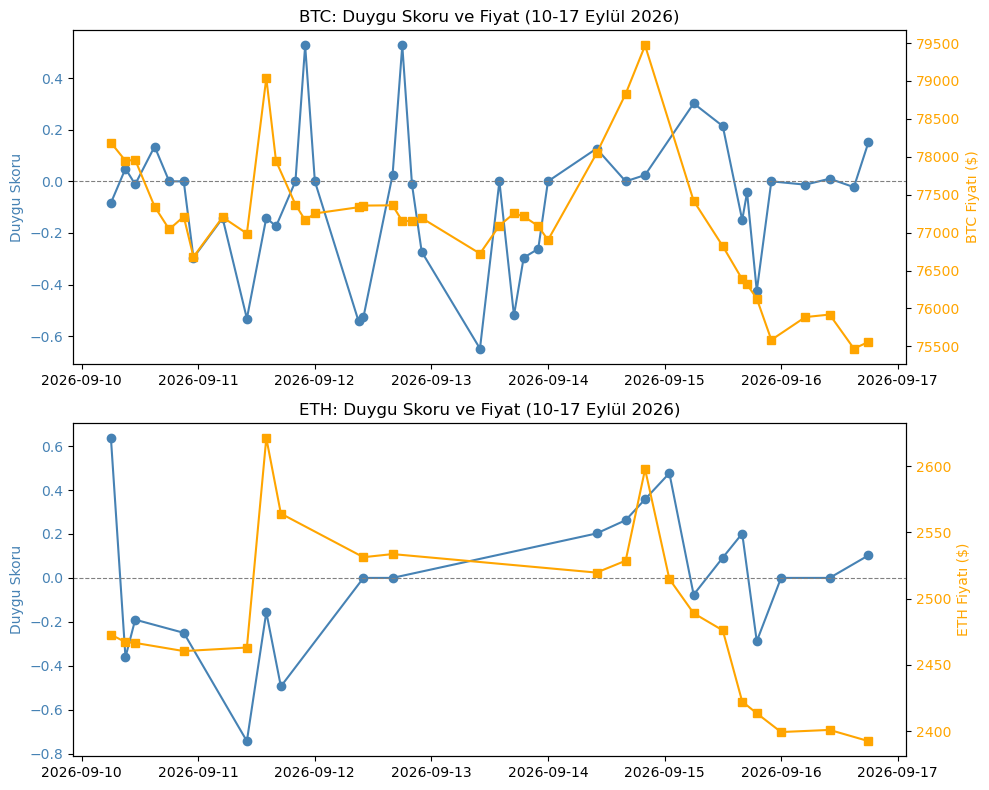

In [37]:
fig, axes = plt.subplots(2, 1, figsize=(10, 8))

for ax, name, merged, color in [(axes[0], 'BTC', btc_merged, 'orange'), (axes[1], 'ETH', eth_merged, 'orange')]:
    ax.plot(merged.index, merged['sentiment'], color='steelblue', marker='o', label='Duygu Skoru')
    ax.set_ylabel('Duygu Skoru', color='steelblue')
    ax.tick_params(axis='y', labelcolor='steelblue')
    ax.axhline(0, color='gray', linestyle='--', linewidth=0.8)

    ax2 = ax.twinx()
    ax2.plot(merged.index, merged['price'], color=color, marker='s', label='Fiyat')
    ax2.set_ylabel(f'{name} Fiyatı ($)', color=color)
    ax2.tick_params(axis='y', labelcolor=color)
    ax.set_title(f'{name}: Duygu Skoru ve Fiyat (10-17 Eylül 2026)')

plt.tight_layout()
plt.savefig('sentiment_price_timeline.png', dpi=150)
plt.show()

## Sonuç ve Değerlendirme

Bu analiz, 8-18 Eylül 2026 tarihleri arasında Reddit ve finans haber RSS kaynaklarından 
(CoinDesk, CoinTelegraph, CryptoSlate) canlı olarak toplanan sentiment verileri (n=611) ile 
aynı dönemde toplanan BTC/ETH fiyat verileri (n=317) kullanılarak yapılmıştır. Sentiment ile 
fiyatın saatlik olarak örtüştüğü, tam bir haftayı (10-17 Eylül 2026) kapsayan pencerede 
BTC için 39, ETH için 20 saatlik eşleşen gözlem elde edilmiştir.

**Betimsel bulgular:** Kripto varlık türüne göre sentiment skorları arasında istatistiksel 
olarak anlamlı bir fark bulunmuştur (tek yönlü ANOVA, F=4.6464, p=0.0099). Bitcoin'e yönelik 
sentiment (ortalama -0.063), Ethereum (+0.009) ve genel kripto içeriklerine (+0.038) kıyasla 
görece daha negatif seyretmiştir.

**Hipotez testi (sentiment ↔ fiyat ilişkisi):** 0-3 saatlik gecikmelerle yapılan Pearson 
korelasyon analizinde, ne BTC ne de ETH için istatistiksel olarak anlamlı bir ilişki 
bulunamamıştır (tüm p-değerleri > 0.05). Bu sonuç, "algı fiyatı mı yönetir, fiyat algıyı mı 
yönetir" sorusuna bu örneklemde net bir yön ortaya koyamamaktadır.

**Sınırlamalar:** Örneklem büyüklüğü (özellikle ETH için n=20 saat) ve gözlem periyodunun 
kısalığı (1 hafta), tespit gücünü sınırlamaktadır. Kripto piyasasının yüksek volatilitesi 
ve sentiment verisinin düzensiz zaman aralıklarıyla toplanması da sonuçları etkilemiş 
olabilir. Daha uzun bir gözlem periyodu, daha sık ve düzenli veri toplama, ve daha büyük 
örneklem büyüklüğü ile bu ilişkinin yeniden test edilmesi önerilmektedir.